# Ablation Study: Enhanced MicroDSC
## Step-by-Step Implementation with Audio Preprocessing and Training

This notebook progressively tests each optimization in the Enhanced MicroDSC model.

**Dataset:** Bird species audio recordings from Rwandan farms

**Classes:** 11 (10 bird species + nonPest)

**Architecture progression:**
- Standard DSC Baseline: ~314.6K parameters
- Enhanced MicroDSC: ~17.4K parameters

**Note:** Each model is trained before evaluation to get meaningful accuracy results.

---
## STEP 1: Import Libraries

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tempfile
import os
import gc
import time

# Audio processing libraries
import librosa
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"Librosa version: {librosa.__version__}")

# Check for GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✓ GPU available: {gpus}")
else:
    print("⚠ No GPU detected, training will use CPU (slower)")

C:\Users\chami\anaconda3\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


✓ Libraries imported successfully
TensorFlow version: 2.12.0
Keras version: 2.12.0
Librosa version: 0.9.2
⚠ No GPU detected, training will use CPU (slower)


---
## STEP 2: Data Preprocessing Functions

These functions load audio files, extract mel frequency energy features, and prepare the data for training.

In [3]:
# ============================================================================
# DATA PREPROCESSING FUNCTIONS
# ============================================================================

def load_and_pad_audio(file_path, target_sr=16000, target_duration=5.0):
    """
    Load audio file and pad/trim to target duration
    
    Args:
        file_path: Path to audio file
        target_sr: Target sample rate (Hz)
        target_duration: Target duration in seconds
    
    Returns:
        y: Audio signal
        sr: Sample rate
    """
    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=target_sr)
        
        # Calculate target length
        target_length = int(target_sr * target_duration)
        
        # Pad or trim audio
        if len(y) > target_length:
            y = y[:target_length]
        elif len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)), mode='constant')
        
        return y, target_sr
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None


def extract_mel_energy(y, sr, n_mels=32, n_fft=1024, hop_length=512):
    """
    Extract mel frequency energy features
    
    Args:
        y: Audio signal
        sr: Sample rate
        n_mels: Number of mel bands
        n_fft: FFT window size
        hop_length: Hop length for STFT
    
    Returns:
        mel_normalized: Normalized mel spectrogram (0-1 range)
    """
    # Extract mel spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=y, 
        sr=sr, 
        n_mels=n_mels, 
        n_fft=n_fft, 
        hop_length=hop_length,
        fmin=50,
        fmax=8000
    )
    
    # Convert to dB scale
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Normalize to [0, 1]
    mel_normalized = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min() + 1e-8)
    
    return mel_normalized


def process_audio_dataset(data_path, target_sr=16000, target_duration=5.0, 
                         n_mels=32, n_fft=1024, hop_length=512):
    """
    Process entire audio dataset from folder structure
    
    Expected folder structure:
    data_path/
        class1/
            audio1.wav
            audio2.wav
        class2/
            audio3.wav
            ...
    
    Args:
        data_path: Root path to dataset
        target_sr: Target sample rate (Hz)
        target_duration: Target duration in seconds
        n_mels: Number of mel bands
        n_fft: FFT window size
        hop_length: Hop length for STFT
    
    Returns:
        features: numpy array of shape (N, n_mels, time_frames, 1)
        labels: numpy array of shape (N,)
        class_names: list of class names
    """
    print(f"🎵 Processing audio dataset from: {data_path}")
    
    # Get class names from folder structure
    class_names = sorted([d for d in os.listdir(data_path) 
                         if os.path.isdir(os.path.join(data_path, d))])
    
    print(f"📂 Found {len(class_names)} classes: {class_names}")
    
    # Collect file paths and labels
    file_paths = []
    labels = []
    
    for class_idx, class_name in enumerate(class_names):
        class_path = os.path.join(data_path, class_name)
        class_files = [f for f in os.listdir(class_path) 
                      if f.lower().endswith(('.wav', '.mp3', '.flac'))]
        
        for file_name in class_files:
            file_paths.append(os.path.join(class_path, file_name))
            labels.append(class_idx)
        
        print(f"   {class_name}: {len(class_files)} files")
    
    print(f"📊 Total files: {len(file_paths)}")
    
    # Process audio files
    features = []
    processed_labels = []
    
    print("🔄 Extracting mel energy features...")
    for file_path, label in tqdm(zip(file_paths, labels), total=len(file_paths)):
        # Load and pad audio
        y, sr = load_and_pad_audio(file_path, target_sr, target_duration)
        
        if y is not None:
            # Extract mel energy features
            mel_features = extract_mel_energy(y, sr, n_mels, n_fft, hop_length)
            
            # Add channel dimension (H, W, C)
            mel_features = np.expand_dims(mel_features, axis=-1)
            
            features.append(mel_features)
            processed_labels.append(label)
    
    # Convert to numpy arrays
    features = np.array(features)
    processed_labels = np.array(processed_labels)
    
    print(f"✅ Processed {len(features)} samples")
    print(f"📏 Features shape: {features.shape}")
    print(f"🏷️ Labels shape: {processed_labels.shape}")
    
    return features, processed_labels, class_names


def prepare_data_for_training(features, labels, test_size=0.2, val_size=0.2, random_state=42):
    """
    Split data into train/validation/test sets
    
    Args:
        features: numpy array of features
        labels: numpy array of labels
        test_size: Proportion for test set (default 0.2 = 20%)
        val_size: Proportion for validation set (default 0.2 = 20%)
        random_state: Random seed for reproducibility
    
    Returns:
        X_train, X_val, X_test: Feature arrays
        y_train, y_val, y_test: Integer labels
    """
    print("🔧 Preparing data for training...")
    
    # First split: separate test set
    X_temp, X_test, y_temp, y_test = train_test_split(
        features, labels, test_size=test_size, random_state=random_state, stratify=labels
    )
    
    # Second split: separate train and validation
    val_size_adjusted = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size_adjusted, random_state=random_state, stratify=y_temp
    )
    
    print(f"   Training: {X_train.shape[0]} samples")
    print(f"   Validation: {X_val.shape[0]} samples") 
    print(f"   Test: {X_test.shape[0]} samples")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

print("✓ Data preprocessing functions defined")

✓ Data preprocessing functions defined


---
## STEP 3: Load and Process our Audio Dataset

In [4]:
data_path = "F:/BirdsPest_DataSet" 

# Audio preprocessing parameters
AUDIO_PARAMS = {
    'target_sr': 16000,        # Sample rate (Hz)
    'target_duration': 5.0,    # Audio clip duration (seconds)
    'n_mels': 32,             # Number of mel bands
    'n_fft': 1024,            # FFT window size
    'hop_length': 512         # Hop length for STFT
}

# Training parameters
TRAINING_PARAMS = {
    'epochs': 50,              # Maximum training epochs
    'batch_size': 32,          # Batch size
    'patience': 10             # Early stopping patience
}

print("Audio Preprocessing Parameters:")
for key, value in AUDIO_PARAMS.items():
    print(f"   {key}: {value}")

print("\nTraining Parameters:")
for key, value in TRAINING_PARAMS.items():
    print(f"   {key}: {value}")

Audio Preprocessing Parameters:
   target_sr: 16000
   target_duration: 5.0
   n_mels: 32
   n_fft: 1024
   hop_length: 512

Training Parameters:
   epochs: 50
   batch_size: 32
   patience: 10


In [5]:
# ============================================================================
# PROCESS AUDIO DATASET
# ============================================================================

# Check if dataset path exists
if not os.path.exists(data_path):
    print(f"❌ Dataset path not found: {data_path}")
    print("Please update the data_path variable in the cell above!")
else:
    # Process the dataset
    features, labels, class_names = process_audio_dataset(
        data_path=data_path,
        **AUDIO_PARAMS
    )
    
    print(f"\n✅ Dataset processed successfully!")
    print(f"   Feature shape: {features.shape}")
    print(f"   Expected input shape for model: (32, {features.shape[2]}, 1)")

🎵 Processing audio dataset from: F:/BirdsPest_DataSet
📂 Found 11 classes: ['bronzeMannkin', 'canary', 'cisticola', 'commonWaxbill', 'greySeedeater', 'nightingale', 'nonPest', 'quelea', 'redFirefinch', 'villageWeaver', 'yellowBishop']
   bronzeMannkin: 906 files
   canary: 907 files
   cisticola: 911 files
   commonWaxbill: 906 files
   greySeedeater: 908 files
   nightingale: 907 files
   nonPest: 907 files
   quelea: 900 files
   redFirefinch: 907 files
   villageWeaver: 904 files
   yellowBishop: 907 files
📊 Total files: 9970
🔄 Extracting mel energy features...


100%|██████████████████████████████████████████████████████████████████████████████| 9970/9970 [07:02<00:00, 23.57it/s]

✅ Processed 9970 samples
📏 Features shape: (9970, 32, 157, 1)
🏷️ Labels shape: (9970,)

✅ Dataset processed successfully!
   Feature shape: (9970, 32, 157, 1)
   Expected input shape for model: (32, 157, 1)


In [6]:
# ============================================================================
# PREPARE TRAIN/VALIDATION/TEST SPLITS
# ============================================================================

# Split data: 60% train, 20% validation, 20% test
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data_for_training(
    features, labels, 
    test_size=0.2, 
    val_size=0.2, 
    random_state=42
)

# Get number of classes and input shape
num_classes = len(class_names)
input_shape = X_train.shape[1:]  # (32, time_frames, 1)

print(f"\n📊 Data Summary:")
print(f"   Input shape: {input_shape}")
print(f"   Number of classes: {num_classes}")
print(f"   Class names: {class_names}")
print(f"\n   Train data shape: {X_train.shape}")
print(f"   Validation data shape: {X_val.shape}")
print(f"   Test data shape: {X_test.shape}")
print(f"   Data range: [{X_train.min():.3f}, {X_train.max():.3f}]")

🔧 Preparing data for training...
   Training: 5982 samples
   Validation: 1994 samples
   Test: 1994 samples

📊 Data Summary:
   Input shape: (32, 157, 1)
   Number of classes: 11
   Class names: ['bronzeMannkin', 'canary', 'cisticola', 'commonWaxbill', 'greySeedeater', 'nightingale', 'nonPest', 'quelea', 'redFirefinch', 'villageWeaver', 'yellowBishop']

   Train data shape: (5982, 32, 157, 1)
   Validation data shape: (1994, 32, 157, 1)
   Test data shape: (1994, 32, 157, 1)
   Data range: [0.000, 1.000]


---
## STEP 4: Create Helper Functions

These functions will train and evaluate each model

In [7]:
def get_model_size_kb(model):
    """
    Get model size in KB by saving to temporary file
    
    """
    # Create temp file path
    tmp_path = os.path.join(tempfile.gettempdir(), f'temp_model_{np.random.randint(100000)}.h5')
    
    try:
        # Save model
        model.save(tmp_path)
        
        # Get file size
        size_bytes = os.path.getsize(tmp_path)
        size_kb = size_bytes / 1024
        
    finally:
        # Try to remove file with retry for Windows
        for attempt in range(5):
            try:
                if os.path.exists(tmp_path):
                    os.remove(tmp_path)
                break
            except PermissionError:
                time.sleep(0.5)  # Wait and retry
    
    return size_kb


def train_and_evaluate_model(model, model_name, X_train, y_train, X_val, y_val, 
                             X_test, y_test, epochs=50, batch_size=32, patience=10):
    """
    Train and evaluate model, returning metrics
    
    Args:
        model: Keras model
        model_name: Name for identification
        X_train, y_train: Training data and labels
        X_val, y_val: Validation data and labels
        X_test, y_test: Test data and labels (integer labels)
        epochs: Number of training epochs
        batch_size: Batch size for training
        patience: Early stopping patience
    
    Returns:
        result: Dictionary with metrics
        history: Training history
    """
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    
    # Count parameters
    params = model.count_params()
    print(f"Parameters: {params:,}")
    
    # Get model size
    size_kb = get_model_size_kb(model)
    print(f"Model size: {size_kb:.2f} KB")
    
    # Compile model
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Early stopping to prevent overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True,
        verbose=1
    )
    
    # Train the model
    print(f"\nTraining for up to {epochs} epochs...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )
    
    # Evaluate on test set
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    accuracy_pct = accuracy * 100
    
    # Get best validation accuracy
    best_val_acc = max(history.history['val_accuracy']) * 100
    
    # Number of epochs actually trained
    epochs_trained = len(history.history['loss'])
    
    result = {
        'Model': model_name,
        'Parameters': params,
        'Size (KB)': round(size_kb, 2),
        'Accuracy (%)': round(accuracy_pct, 2),
        'Val Accuracy (%)': round(best_val_acc, 2),
        'Epochs': epochs_trained
    }
    
    print(f"\n✓ {model_name}")
    print(f"   Test Accuracy: {accuracy_pct:.2f}%")
    print(f"   Best Val Accuracy: {best_val_acc:.2f}%")
    print(f"   Epochs trained: {epochs_trained}")
    
    return result, history


print("✓ Helper functions created (with training)")

✓ Helper functions created (with training)


---
## STEP 5: Build and Train Model 1 - Standard DSC (Baseline)

This is the reference model with traditional DSC features:
- Filter scaling: 16 → 32 → 64 → 128
- Bias terms in all layers
- ReLU activation
- Flatten + Dense(128) layers

In [8]:
def build_model_1_baseline(input_shape, num_classes):
    """
    Standard DSC with traditional features:
    - Filter scaling: 16 → 32 → 64 → 128
    - Bias terms in all layers (use_bias=True)
    - ReLU activation
    - Flatten + Dense(128) classification head
    
    Expected: ~314.6K parameters
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        
        # Initial Convolution (16 filters)
        layers.Conv2D(16, (3, 3), strides=2, padding='same', use_bias=True),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        
        # Block 1 (32 filters)
        layers.SeparableConv2D(32, (3, 3), padding='same', use_bias=True),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2 (64 filters)
        layers.SeparableConv2D(64, (3, 3), padding='same', use_bias=True),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3 (128 filters)
        layers.SeparableConv2D(128, (3, 3), padding='same', use_bias=True),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Classification (traditional: Flatten + Dense)
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

print("[1/5] Building Model 1: Standard DSC (Baseline)...")
model_1 = build_model_1_baseline(input_shape, num_classes)
print("✓ Model 1 built")
print(f"\nExpected: ~314,600 parameters")
print(f"Actual: {model_1.count_params():,} parameters")
model_1.summary()

[1/5] Building Model 1: Standard DSC (Baseline)...
✓ Model 1 built

Expected: ~314,600 parameters
Actual: 309,563 parameters
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 16, 79, 16)        160       
                                                                 
 batch_normalization (BatchN  (None, 16, 79, 16)       64        
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 16, 79, 16)        0         
                                                                 
 separable_conv2d (Separable  (None, 16, 79, 32)       688       
 Conv2D)                                                         
                                                                 
 batch_normalization_1 (Batc  (None, 16, 79, 32)       128     

In [9]:
# Train and evaluate Model 1
result_1, history_1 = train_and_evaluate_model(
    model_1, 
    "Standard DSC (Baseline)", 
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    epochs=TRAINING_PARAMS['epochs'],
    batch_size=TRAINING_PARAMS['batch_size'],
    patience=TRAINING_PARAMS['patience']
)

print(f"\n{'='*60}")
print("MODEL 1 RESULTS: Standard DSC (Baseline)")
print(f"{'='*60}")
for key, value in result_1.items():
    print(f"{key:20s}: {value}")
print(f"{'='*60}")


Training: Standard DSC (Baseline)
Parameters: 309,563
Model size: 1263.97 KB

Training for up to 50 epochs...
Epoch 1/50
187/187 [==============================] - 10s 46ms/step - loss: 1.3966 - accuracy: 0.5304 - val_loss: 2.4628 - val_accuracy: 0.0913
Epoch 2/50
187/187 [==============================] - 8s 44ms/step - loss: 0.5593 - accuracy: 0.8186 - val_loss: 2.3524 - val_accuracy: 0.1459
Epoch 3/50
187/187 [==============================] - 9s 46ms/step - loss: 0.3349 - accuracy: 0.8927 - val_loss: 0.6727 - val_accuracy: 0.7758
Epoch 4/50
187/187 [==============================] - 8s 44ms/step - loss: 0.2043 - accuracy: 0.9351 - val_loss: 0.1616 - val_accuracy: 0.9519
Epoch 5/50
187/187 [==============================] - 8s 43ms/step - loss: 0.1542 - accuracy: 0.9529 - val_loss: 0.1707 - val_accuracy: 0.9463
Epoch 6/50
187/187 [==============================] - 8s 44ms/step - loss: 0.1403 - accuracy: 0.9534 - val_loss: 0.1857 - val_accuracy: 0.9488
Epoch 7/50
187/187 [==========

---
## STEP 6: Build and Train Model 2 - Filter Reduction

**Optimization 1:** Reduce filter scaling from (16→32→64→128) to (16→32→48→64)

Changes:
- Block 2: 64 → 48 filters
- Block 3: 128 → 64 filters
- Dense layer: 128 → 64 units

In [10]:
def build_model_2_filter_reduction(input_shape, num_classes):
    """
    With filter reduction:
    - Filter scaling: 16 → 32 → 48 → 64 (conservative)
    - Still has bias terms
    - Still uses ReLU
    - Dense layer reduced to 64 units
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        
        # Initial Convolution (16 filters - unchanged)
        layers.Conv2D(16, (3, 3), strides=2, padding='same', use_bias=True),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        
        # Block 1 (32 filters - unchanged)
        layers.SeparableConv2D(32, (3, 3), padding='same', use_bias=True),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2 (48 filters - reduced from 64)
        layers.SeparableConv2D(48, (3, 3), padding='same', use_bias=True),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3 (64 filters - reduced from 128)
        layers.SeparableConv2D(64, (3, 3), padding='same', use_bias=True),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Classification (Dense reduced to 64)
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

print("[2/5] Building Model 2: + Filter Reduction...")
model_2 = build_model_2_filter_reduction(input_shape, num_classes)
print("✓ Model 2 built")
print(f"Actual: {model_2.count_params():,} parameters")
model_2.summary()

[2/5] Building Model 2: + Filter Reduction...
✓ Model 2 built
Actual: 81,435 parameters
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 16, 79, 16)        160       
                                                                 
 batch_normalization_4 (Batc  (None, 16, 79, 16)       64        
 hNormalization)                                                 
                                                                 
 activation_4 (Activation)   (None, 16, 79, 16)        0         
                                                                 
 separable_conv2d_3 (Separab  (None, 16, 79, 32)       688       
 leConv2D)                                                       
                                                                 
 batch_normalization_5 (Batc  (None, 16, 79, 32)       128       
 hNormalization)                

In [11]:
# Train and evaluate Model 2
result_2, history_2 = train_and_evaluate_model(
    model_2, 
    "+ Filter Reduction", 
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    epochs=TRAINING_PARAMS['epochs'],
    batch_size=TRAINING_PARAMS['batch_size'],
    patience=TRAINING_PARAMS['patience']
)

print(f"\n{'='*60}")
print("MODEL 2 RESULTS: + Filter Reduction")
print(f"{'='*60}")
for key, value in result_2.items():
    print(f"{key:20s}: {value}")

# Calculate improvement over baseline
param_reduction = ((result_1['Parameters'] - result_2['Parameters']) / result_1['Parameters']) * 100
size_reduction = ((result_1['Size (KB)'] - result_2['Size (KB)']) / result_1['Size (KB)']) * 100
accuracy_change = result_2['Accuracy (%)'] - result_1['Accuracy (%)']

print(f"\n--- Improvement over Baseline ---")
print(f"Parameter Reduction: {param_reduction:.1f}%")
print(f"Size Reduction: {size_reduction:.1f}%")
print(f"Accuracy Change: {accuracy_change:+.2f}%")
print(f"{'='*60}")


Training: + Filter Reduction
Parameters: 81,435
Model size: 373.07 KB

Training for up to 50 epochs...
Epoch 1/50
187/187 [==============================] - 9s 39ms/step - loss: 1.6253 - accuracy: 0.4381 - val_loss: 2.4147 - val_accuracy: 0.0913
Epoch 2/50
187/187 [==============================] - 7s 38ms/step - loss: 0.7940 - accuracy: 0.7347 - val_loss: 2.3733 - val_accuracy: 0.2412
Epoch 3/50
187/187 [==============================] - 7s 38ms/step - loss: 0.5062 - accuracy: 0.8315 - val_loss: 0.7060 - val_accuracy: 0.7859
Epoch 4/50
187/187 [==============================] - 7s 37ms/step - loss: 0.3557 - accuracy: 0.8793 - val_loss: 0.4471 - val_accuracy: 0.8440
Epoch 5/50
187/187 [==============================] - 7s 38ms/step - loss: 0.2775 - accuracy: 0.9132 - val_loss: 0.2237 - val_accuracy: 0.9233
Epoch 6/50
187/187 [==============================] - 7s 37ms/step - loss: 0.2074 - accuracy: 0.9318 - val_loss: 0.1195 - val_accuracy: 0.9659
Epoch 7/50
187/187 [==================

---
## STEP 7: Build and Train Model 3 - Remove Biases

**Optimization 2:** Remove bias terms from convolutional layers (`use_bias=False`)

Rationale: BatchNormalization absorbs the bias function, making explicit biases redundant.

In [12]:
def build_model_3_no_bias(input_shape, num_classes):
    """
    With bias removal:
    - Filter scaling: 16 → 32 → 48 → 64
    - NO bias terms in conv layers (use_bias=False)
    - Still uses ReLU
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        
        # Initial Convolution (NO bias)
        layers.Conv2D(16, (3, 3), strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        
        # Block 1 (NO bias)
        layers.SeparableConv2D(32, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2 (NO bias)
        layers.SeparableConv2D(48, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3 (NO bias)
        layers.SeparableConv2D(64, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Classification
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

print("[3/5] Building Model 3: + Remove Biases...")
model_3 = build_model_3_no_bias(input_shape, num_classes)
print("✓ Model 3 built")
print(f"Actual: {model_3.count_params():,} parameters")
model_3.summary()

[3/5] Building Model 3: + Remove Biases...
✓ Model 3 built
Actual: 81,275 parameters
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 16, 79, 16)        144       
                                                                 
 batch_normalization_8 (Batc  (None, 16, 79, 16)       64        
 hNormalization)                                                 
                                                                 
 activation_8 (Activation)   (None, 16, 79, 16)        0         
                                                                 
 separable_conv2d_6 (Separab  (None, 16, 79, 32)       656       
 leConv2D)                                                       
                                                                 
 batch_normalization_9 (Batc  (None, 16, 79, 32)       128       
 hNormalization)                   

In [15]:
# Train and evaluate Model 3
result_3, history_3 = train_and_evaluate_model(
    model_3, 
    "+ Remove Biases", 
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    epochs=TRAINING_PARAMS['epochs'],
    batch_size=TRAINING_PARAMS['batch_size'],
    patience=TRAINING_PARAMS['patience']
)

print(f"\n{'='*60}")
print("MODEL 3 RESULTS: + Remove Biases")
print(f"{'='*60}")
for key, value in result_3.items():
    print(f"{key:20s}: {value}")

# Calculate improvement
param_reduction = ((result_2['Parameters'] - result_3['Parameters']) / result_2['Parameters']) * 100
size_reduction = ((result_2['Size (KB)'] - result_3['Size (KB)']) / result_2['Size (KB)']) * 100
accuracy_change = result_3['Accuracy (%)'] - result_2['Accuracy (%)']

print(f"\n--- Improvement over Model 2 ---")
print(f"Parameter Reduction: {param_reduction:.1f}%")
print(f"Size Reduction: {size_reduction:.1f}%")
print(f"Accuracy Change: {accuracy_change:+.2f}%")
print(f"{'='*60}")


Training: + Remove Biases
Parameters: 81,275
Model size: 372.23 KB

Training for up to 50 epochs...
Epoch 1/50
187/187 [==============================] - 9s 40ms/step - loss: 1.4148 - accuracy: 0.5169 - val_loss: 2.4486 - val_accuracy: 0.0913
Epoch 2/50
187/187 [==============================] - 8s 41ms/step - loss: 0.6176 - accuracy: 0.8014 - val_loss: 2.3879 - val_accuracy: 0.1369
Epoch 3/50
187/187 [==============================] - 8s 42ms/step - loss: 0.3599 - accuracy: 0.8882 - val_loss: 0.4688 - val_accuracy: 0.8606
Epoch 4/50
187/187 [==============================] - 7s 39ms/step - loss: 0.2601 - accuracy: 0.9162 - val_loss: 0.1393 - val_accuracy: 0.9594
Epoch 5/50
187/187 [==============================] - 7s 38ms/step - loss: 0.1940 - accuracy: 0.9390 - val_loss: 0.1840 - val_accuracy: 0.9433
Epoch 6/50
187/187 [==============================] - 7s 38ms/step - loss: 0.1522 - accuracy: 0.9545 - val_loss: 0.1351 - val_accuracy: 0.9634
Epoch 7/50
187/187 [=====================

---
## STEP 8: Build and Train Model 4 - ReLU6 Activation

**Optimization 3:** Replace ReLU with ReLU6 (bounded output: [0, 6])

Rationale: ReLU6 provides bounded activations that are more compatible with INT8 quantization.

In [16]:
def build_model_4_relu6(input_shape, num_classes):
    """
    With ReLU6 activation:
    - Filter scaling: 16 → 32 → 48 → 64
    - No bias terms
    - ReLU6 activation (quantization-friendly, bounded [0, 6])
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        
        # Initial Convolution
        layers.Conv2D(16, (3, 3), strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(max_value=6),  # ReLU6
        
        # Block 1
        layers.SeparableConv2D(32, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(max_value=6),  # ReLU6
        layers.MaxPooling2D((2, 2)),
        
        # Block 2
        layers.SeparableConv2D(48, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(max_value=6),  # ReLU6
        layers.MaxPooling2D((2, 2)),
        
        # Block 3
        layers.SeparableConv2D(64, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(max_value=6),  # ReLU6
        layers.MaxPooling2D((2, 2)),
        
        # Classification
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

print("[4/5] Building Model 4: + ReLU6 Activation...")
model_4 = build_model_4_relu6(input_shape, num_classes)
print("✓ Model 4 built")
print(f"Actual: {model_4.count_params():,} parameters")
model_4.summary()

[4/5] Building Model 4: + ReLU6 Activation...
✓ Model 4 built
Actual: 81,275 parameters
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 16, 79, 16)        144       
                                                                 
 batch_normalization_16 (Bat  (None, 16, 79, 16)       64        
 chNormalization)                                                
                                                                 
 re_lu_4 (ReLU)              (None, 16, 79, 16)        0         
                                                                 
 separable_conv2d_12 (Separa  (None, 16, 79, 32)       656       
 bleConv2D)                                                      
                                                                 
 batch_normalization_17 (Bat  (None, 16, 79, 32)       128       
 chNormalization)               

In [17]:
# Train and evaluate Model 4
result_4, history_4 = train_and_evaluate_model(
    model_4, 
    "+ ReLU6 Activation", 
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    epochs=TRAINING_PARAMS['epochs'],
    batch_size=TRAINING_PARAMS['batch_size'],
    patience=TRAINING_PARAMS['patience']
)

print(f"\n{'='*60}")
print("MODEL 4 RESULTS: + ReLU6 Activation")
print(f"{'='*60}")
for key, value in result_4.items():
    print(f"{key:20s}: {value}")

# Calculate improvement
param_reduction = ((result_3['Parameters'] - result_4['Parameters']) / result_3['Parameters']) * 100
size_reduction = ((result_3['Size (KB)'] - result_4['Size (KB)']) / result_3['Size (KB)']) * 100
accuracy_change = result_4['Accuracy (%)'] - result_3['Accuracy (%)']

print(f"\n--- Improvement over Model 3 ---")
print(f"Parameter Reduction: {param_reduction:.1f}%")
print(f"Size Reduction: {size_reduction:.1f}%")
print(f"Accuracy Change: {accuracy_change:+.2f}%")
print(f"{'='*60}")


Training: + ReLU6 Activation
Parameters: 81,275
Model size: 371.78 KB

Training for up to 50 epochs...
Epoch 1/50
187/187 [==============================] - 8s 38ms/step - loss: 1.3573 - accuracy: 0.5361 - val_loss: 2.4636 - val_accuracy: 0.0908
Epoch 2/50
187/187 [==============================] - 8s 40ms/step - loss: 0.5991 - accuracy: 0.8017 - val_loss: 2.3477 - val_accuracy: 0.2242
Epoch 3/50
187/187 [==============================] - 7s 37ms/step - loss: 0.3447 - accuracy: 0.8868 - val_loss: 0.3995 - val_accuracy: 0.9042
Epoch 4/50
187/187 [==============================] - 7s 37ms/step - loss: 0.2495 - accuracy: 0.9204 - val_loss: 0.1489 - val_accuracy: 0.9539
Epoch 5/50
187/187 [==============================] - 7s 37ms/step - loss: 0.1970 - accuracy: 0.9397 - val_loss: 0.1250 - val_accuracy: 0.9599
Epoch 6/50
187/187 [==============================] - 7s 37ms/step - loss: 0.1477 - accuracy: 0.9522 - val_loss: 0.2089 - val_accuracy: 0.9348
Epoch 7/50
187/187 [==================

---
## STEP 9: Build and Train Model 5 - Global Average Pooling (Enhanced MicroDSC)

**Optimization 4:** Replace Flatten + Dense with Global Average Pooling

This is the final Enhanced MicroDSC architecture!

In [18]:
def build_model_5_gap(input_shape, num_classes):
    """
    Enhanced MicroDSC with Global Average Pooling:
    - Filter scaling: 16 → 32 → 48 → 64
    - No bias terms
    - ReLU6 activation
    - Global Average Pooling (replaces Flatten + Dense)
    
    Expected: ~17.4K parameters
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        
        # Initial Convolution
        layers.Conv2D(16, (3, 3), strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(max_value=6),
        
        # Block 1
        layers.SeparableConv2D(32, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(max_value=6),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2
        layers.SeparableConv2D(48, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(max_value=6),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3
        layers.SeparableConv2D(64, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(max_value=6),
        layers.MaxPooling2D((2, 2)),
        
        # Classification (Global Average Pooling - key optimization)
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

print("[5/5] Building Model 5: Enhanced MicroDSC (+ Global Average Pooling)...")
model_5 = build_model_5_gap(input_shape, num_classes)
print("✓ Model 5 built")
print(f"\nExpected: ~17,400 parameters")
print(f"Actual: {model_5.count_params():,} parameters")
model_5.summary()

[5/5] Building Model 5: Enhanced MicroDSC (+ Global Average Pooling)...
✓ Model 5 built

Expected: ~17,400 parameters
Actual: 7,483 parameters
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 16, 79, 16)        144       
                                                                 
 batch_normalization_20 (Bat  (None, 16, 79, 16)       64        
 chNormalization)                                                
                                                                 
 re_lu_8 (ReLU)              (None, 16, 79, 16)        0         
                                                                 
 separable_conv2d_15 (Separa  (None, 16, 79, 32)       656       
 bleConv2D)                                                      
                                                                 
 batch_normalization_21 (Bat  (None, 16, 79

In [19]:
# Train and evaluate Model 5
result_5, history_5 = train_and_evaluate_model(
    model_5, 
    "Enhanced MicroDSC (+ GAP)", 
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    epochs=TRAINING_PARAMS['epochs'],
    batch_size=TRAINING_PARAMS['batch_size'],
    patience=TRAINING_PARAMS['patience']
)

print(f"\n{'='*60}")
print("MODEL 5 RESULTS: Enhanced MicroDSC (+ GAP)")
print(f"{'='*60}")
for key, value in result_5.items():
    print(f"{key:20s}: {value}")

# Calculate improvement
param_reduction = ((result_4['Parameters'] - result_5['Parameters']) / result_4['Parameters']) * 100
size_reduction = ((result_4['Size (KB)'] - result_5['Size (KB)']) / result_4['Size (KB)']) * 100
accuracy_change = result_5['Accuracy (%)'] - result_4['Accuracy (%)']

print(f"\n--- Improvement over Model 4 ---")
print(f"Parameter Reduction: {param_reduction:.1f}%")
print(f"Size Reduction: {size_reduction:.1f}%")
print(f"Accuracy Change: {accuracy_change:+.2f}%")
print(f"{'='*60}")


Training: Enhanced MicroDSC (+ GAP)
Parameters: 7,483
Model size: 81.10 KB

Training for up to 50 epochs...
Epoch 1/50
187/187 [==============================] - 8s 38ms/step - loss: 1.5007 - accuracy: 0.5122 - val_loss: 2.4511 - val_accuracy: 0.0913
Epoch 2/50
187/187 [==============================] - 7s 37ms/step - loss: 0.7437 - accuracy: 0.7972 - val_loss: 2.5576 - val_accuracy: 0.0913
Epoch 3/50
187/187 [==============================] - 7s 36ms/step - loss: 0.4618 - accuracy: 0.8766 - val_loss: 0.7215 - val_accuracy: 0.7954
Epoch 4/50
187/187 [==============================] - 7s 37ms/step - loss: 0.3255 - accuracy: 0.9193 - val_loss: 0.3077 - val_accuracy: 0.9147
Epoch 5/50
187/187 [==============================] - 7s 38ms/step - loss: 0.2370 - accuracy: 0.9407 - val_loss: 0.2976 - val_accuracy: 0.9127
Epoch 6/50
187/187 [==============================] - 7s 37ms/step - loss: 0.1935 - accuracy: 0.9485 - val_loss: 0.2060 - val_accuracy: 0.9378
Epoch 7/50
187/187 [=============

---
## STEP 10: Compile All Results

In [20]:
# Collect all results
all_results = [result_1, result_2, result_3, result_4, result_5]

# Create DataFrame
df = pd.DataFrame(all_results)

# Add incremental changes
df['Param Δ (%)'] = [0] + [round(((all_results[i-1]['Parameters'] - all_results[i]['Parameters']) / all_results[i-1]['Parameters']) * 100, 1) for i in range(1, len(all_results))]
df['Size Δ (%)'] = [0] + [round(((all_results[i-1]['Size (KB)'] - all_results[i]['Size (KB)']) / all_results[i-1]['Size (KB)']) * 100, 1) for i in range(1, len(all_results))]
df['Acc Δ (%)'] = [0] + [round(all_results[i]['Accuracy (%)'] - all_results[i-1]['Accuracy (%)'], 2) for i in range(1, len(all_results))]

print("\n" + "="*120)
print("ABLATION STUDY RESULTS")
print("="*120)
print(df.to_string(index=False))
print("="*120)

# Calculate cumulative improvements
baseline_params = result_1['Parameters']
final_params = result_5['Parameters']
baseline_size = result_1['Size (KB)']
final_size = result_5['Size (KB)']
baseline_acc = result_1['Accuracy (%)']
final_acc = result_5['Accuracy (%)']

param_reduction_total = ((baseline_params - final_params) / baseline_params) * 100
size_reduction_total = ((baseline_size - final_size) / baseline_size) * 100
acc_change_total = final_acc - baseline_acc

print(f"\nCUMULATIVE IMPROVEMENT (Baseline → Enhanced MicroDSC):")
print(f"   Parameters: {baseline_params:,} → {final_params:,} ({param_reduction_total:.1f}% reduction)")
print(f"   Model Size: {baseline_size:.2f} KB → {final_size:.2f} KB ({size_reduction_total:.1f}% reduction)")
print(f"   Accuracy: {baseline_acc:.2f}% → {final_acc:.2f}% ({acc_change_total:+.2f}%)")

# Verify parameter counts match expected values
print(f"\n📊 PARAMETER COUNT VERIFICATION:")
print(f"   Standard DSC Baseline: {baseline_params:,} (expected ~314,600)")
print(f"   Enhanced MicroDSC: {final_params:,} (expected ~17,400)")


ABLATION STUDY RESULTS
                    Model  Parameters  Size (KB)  Accuracy (%)  Val Accuracy (%)  Epochs  Param Δ (%)  Size Δ (%)  Acc Δ (%)
  Standard DSC (Baseline)      309563    1263.97         98.19             98.19      20          0.0         0.0       0.00
       + Filter Reduction       81435     373.07         97.84             97.69      22         73.7        70.5      -0.35
          + Remove Biases       81275     372.23         98.09             98.24      28          0.2         0.2       0.25
       + ReLU6 Activation       81275     371.78         98.24             98.45      23          0.0         0.1       0.15
Enhanced MicroDSC (+ GAP)        7483      81.10         98.85             98.70      28         90.8        78.2       0.61

CUMULATIVE IMPROVEMENT (Baseline → Enhanced MicroDSC):
   Parameters: 309,563 → 7,483 (97.6% reduction)
   Model Size: 1263.97 KB → 81.10 KB (93.6% reduction)
   Accuracy: 98.19% → 98.85% (+0.66%)

📊 PARAMETER COUNT VERIFICAT

---
## STEP 11: Visualize Training Histories

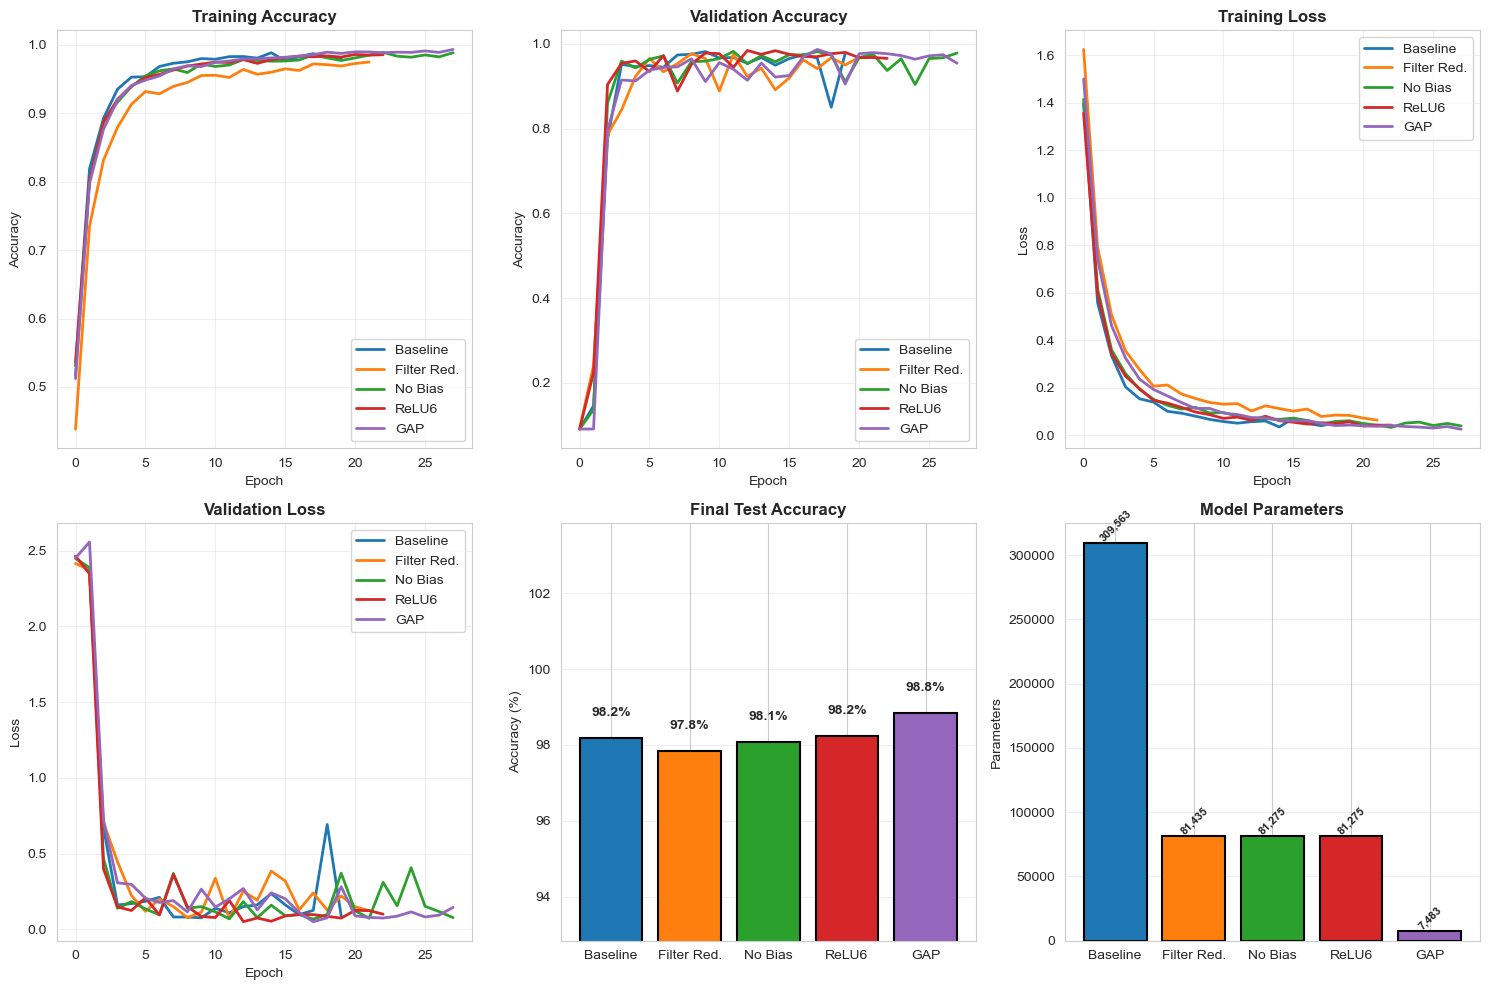

✓ Training history visualization saved as 'ablation_training_history.png'


In [21]:
# Plot training histories for all models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

histories = [history_1, history_2, history_3, history_4, history_5]
model_names_short = ['Baseline', 'Filter Red.', 'No Bias', 'ReLU6', 'GAP']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Plot training accuracy
ax1 = axes[0, 0]
for i, (hist, name, color) in enumerate(zip(histories, model_names_short, colors)):
    ax1.plot(hist.history['accuracy'], label=name, color=color, linewidth=2)
ax1.set_title('Training Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot validation accuracy
ax2 = axes[0, 1]
for i, (hist, name, color) in enumerate(zip(histories, model_names_short, colors)):
    ax2.plot(hist.history['val_accuracy'], label=name, color=color, linewidth=2)
ax2.set_title('Validation Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot training loss
ax3 = axes[0, 2]
for i, (hist, name, color) in enumerate(zip(histories, model_names_short, colors)):
    ax3.plot(hist.history['loss'], label=name, color=color, linewidth=2)
ax3.set_title('Training Loss', fontweight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Loss')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot validation loss
ax4 = axes[1, 0]
for i, (hist, name, color) in enumerate(zip(histories, model_names_short, colors)):
    ax4.plot(hist.history['val_loss'], label=name, color=color, linewidth=2)
ax4.set_title('Validation Loss', fontweight='bold')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Loss')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Final test accuracy comparison
ax5 = axes[1, 1]
test_accs = [r['Accuracy (%)'] for r in all_results]
bars = ax5.bar(model_names_short, test_accs, color=colors, edgecolor='black', linewidth=1.5)
ax5.set_title('Final Test Accuracy', fontweight='bold')
ax5.set_ylabel('Accuracy (%)')
ax5.set_ylim([min(test_accs) - 5, max(test_accs) + 5])
for bar, val in zip(bars, test_accs):
    ax5.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

# Parameter comparison
ax6 = axes[1, 2]
params_list = [r['Parameters'] for r in all_results]
bars6 = ax6.bar(model_names_short, params_list, color=colors, edgecolor='black', linewidth=1.5)
ax6.set_title('Model Parameters', fontweight='bold')
ax6.set_ylabel('Parameters')
for bar, val in zip(bars6, params_list):
    ax6.text(bar.get_x() + bar.get_width()/2, val, f'{val:,}', 
             ha='center', va='bottom', fontsize=8, fontweight='bold', rotation=45)
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ablation_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training history visualization saved as 'ablation_training_history.png'")

---
## STEP 12: Visualize Ablation Study Results

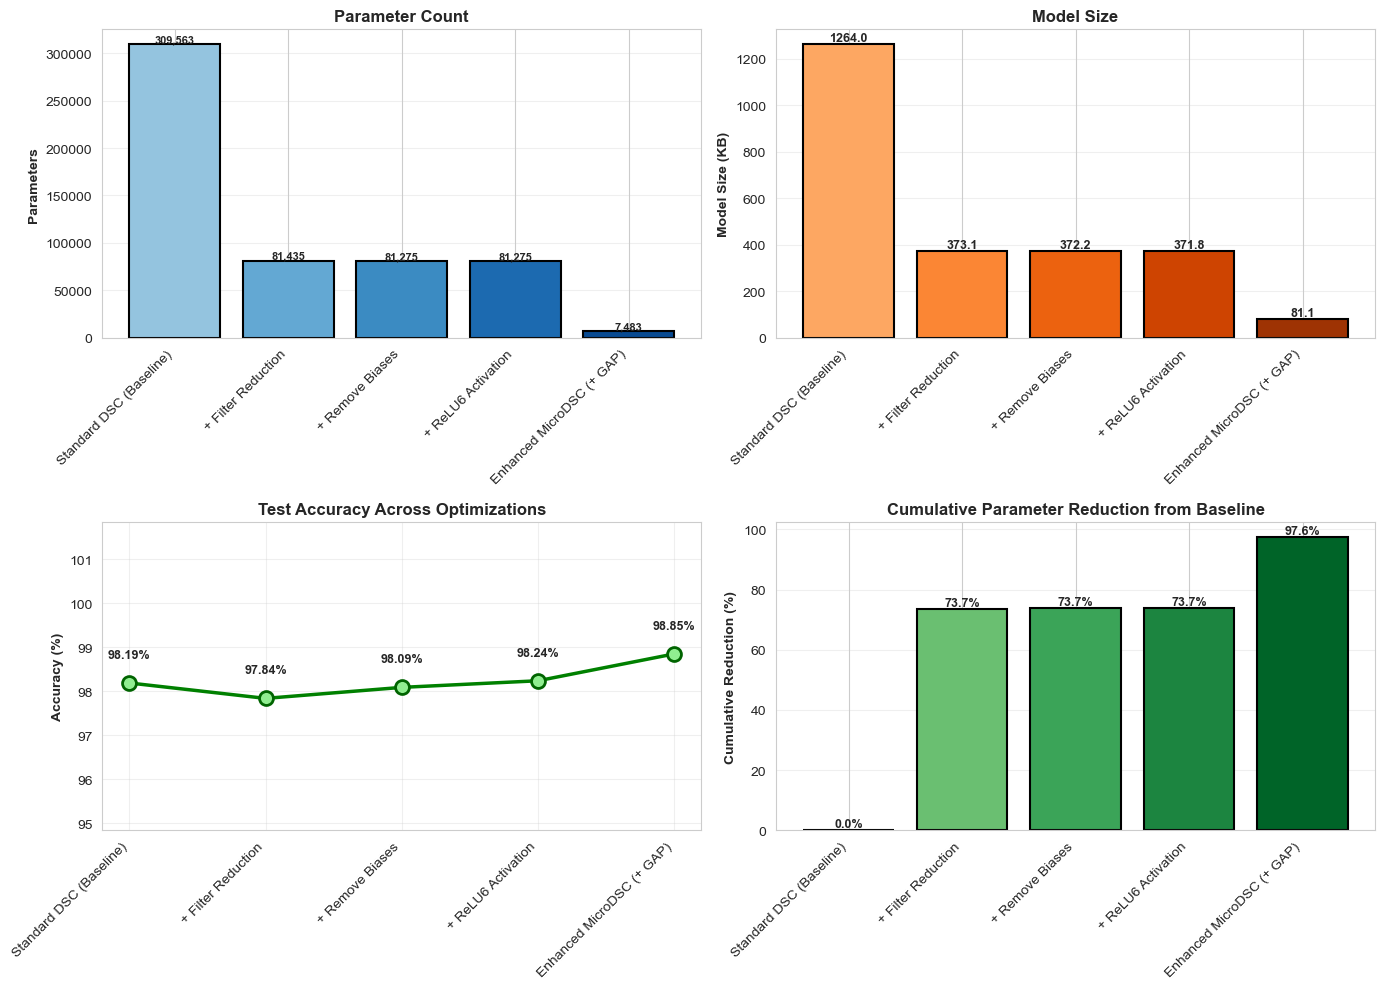

✓ Visualization saved as 'ablation_study_analysis.png'


In [22]:
# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

model_names = [r['Model'] for r in all_results]
x_pos = np.arange(len(model_names))

# Plot 1: Parameters
ax1 = axes[0, 0]
params = [r['Parameters'] for r in all_results]
colors1 = plt.cm.Blues(np.linspace(0.4, 0.9, len(all_results)))
bars1 = ax1.bar(x_pos, params, color=colors1, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Parameters', fontweight='bold')
ax1.set_title('Parameter Count', fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)
# Add value labels
for i, (bar, val) in enumerate(zip(bars1, params)):
    ax1.text(bar.get_x() + bar.get_width()/2, val, f'{val:,}', 
            ha='center', va='bottom', fontsize=8, fontweight='bold')

# Plot 2: Model Size
ax2 = axes[0, 1]
sizes = [r['Size (KB)'] for r in all_results]
colors2 = plt.cm.Oranges(np.linspace(0.4, 0.9, len(all_results)))
bars2 = ax2.bar(x_pos, sizes, color=colors2, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Model Size (KB)', fontweight='bold')
ax2.set_title('Model Size', fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)
# Add value labels
for i, (bar, val) in enumerate(zip(bars2, sizes)):
    ax2.text(bar.get_x() + bar.get_width()/2, val, f'{val:.1f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Accuracy
ax3 = axes[1, 0]
accuracies = [r['Accuracy (%)'] for r in all_results]
ax3.plot(x_pos, accuracies, marker='o', linewidth=2.5, markersize=10, 
         color='green', markerfacecolor='lightgreen', markeredgecolor='darkgreen', markeredgewidth=2)
ax3.set_ylabel('Accuracy (%)', fontweight='bold')
ax3.set_title('Test Accuracy Across Optimizations', fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(model_names, rotation=45, ha='right')
ax3.grid(True, alpha=0.3)
# Smart y-axis scaling
y_min = min(accuracies) - 3
y_max = max(accuracies) + 3
ax3.set_ylim([y_min, y_max])
# Add value labels
for i, (xi, yi) in enumerate(zip(x_pos, accuracies)):
    ax3.text(xi, yi + 0.5, f'{yi:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 4: Cumulative Parameter Reduction
ax4 = axes[1, 1]
reductions = [
    ((baseline_params - r['Parameters']) / baseline_params * 100)
    for r in all_results
]
colors4 = plt.cm.Greens(np.linspace(0.4, 0.9, len(all_results)))
bars4 = ax4.bar(x_pos, reductions, color=colors4, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Cumulative Reduction (%)', fontweight='bold')
ax4.set_title('Cumulative Parameter Reduction from Baseline', fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(model_names, rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)
# Add value labels
for i, (bar, val) in enumerate(zip(bars4, reductions)):
    ax4.text(bar.get_x() + bar.get_width()/2, val, f'{val:.1f}%', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('ablation_study_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as 'ablation_study_analysis.png'")